In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

In [2]:
a1 = -0.75
b1 = -0.25
a2 = 0.25
b2 = 0.75
eps = 0.05
T = 1
yt = 1

In [3]:
y01 = np.random.uniform(low=a1, high=b1, size=[1000000, 1])
y02 = np.random.uniform(low=a2, high=b2, size=[1000000, 1])
y0 = np.concatenate([y01, y02], axis=0)

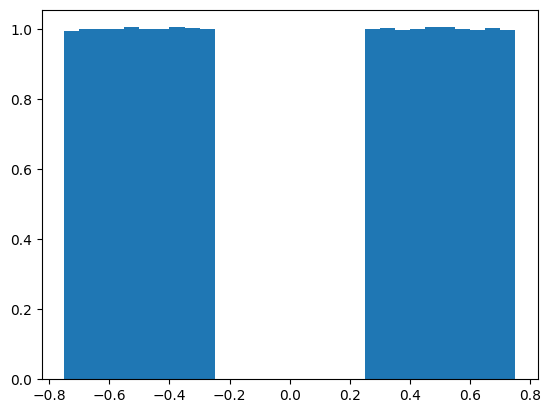

In [4]:
plt.hist(y0.flatten(), bins=30, density=True)
plt.show()

In [5]:
Nt = 101
t = np.linspace(0, T, Nt)
ys = [y0]
dt = t[1] - t[0]
for i in range(int(T/dt)):
    ys += [ys[-1] + np.sqrt(dt * eps) * np.random.normal(size=y0.shape)]
ys = np.stack(ys)[..., 0].T

In [6]:
sio.savemat(
    "./train5.mat",
    {
        "t": t,
        "y0_train": ys[:int(ys.shape[0]/2), :],
        "y1_train": ys[int(ys.shape[0]/2):, :],
        "eps": eps,
        "T": T,
    }
)